# PyTorch Tutorial

Paul J. Atzberger<br> 
<https://web.atzberger.org/>

# MLP Regression: Fitting a 2D Function

We show here how to train a neural network from scratch using the skills we developed in the previous notebooks. We show how to train a **multi-layer perceptron (MLP)** that learns to reproduce a 2D function. This is done by using observations during training of $f$ evaluated at some sample coordinate pairs $(x,y)$.

### The target function

We will fit the **damped circular ripple** function:

$$f(x, y) = \sin(5r) \cdot e^{-0.4r}, \quad r = \sqrt{x^2 + y^2}$$

This gives concentric rings that oscillate and decay outward. This is similar to when a pebble is thrown into a pond and the waves that form on the surface. This provides a smooth bounded function for the MLP to try to learn. 

### Aims for the MLP Neural Network 

```
Input:   (x, y)  : a 2-D coordinate
Output:  z       : the scalar function value at that point
```

**Intution:** The neural network never sees the formula. It must discover the pattern purely from sampled training data by minimizing the mean-squared error (MSE). We will try to learn the parameters of the model (train the model) by using the Adam optimizer.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu126


---
## Define the Target Function and Generate Data

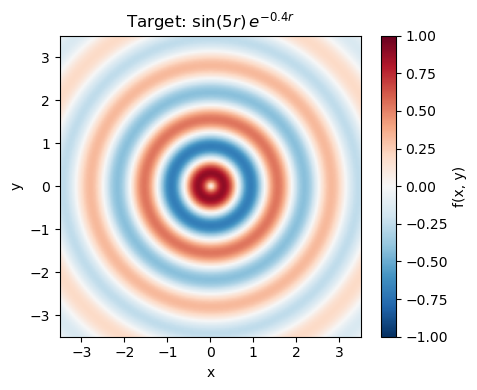

In [2]:
def target_fn(x, y):
    r = torch.sqrt(x**2 + y**2)
    return torch.sin(5.0 * r) * torch.exp(-0.4 * r)

# --- Visualize the target on a dense grid ---
GRID_N = 200
extent = 3.5
grid_vals = torch.linspace(-extent, extent, GRID_N)

# meshgrid returns two (GRID_N, GRID_N) tensors
gx, gy = torch.meshgrid(grid_vals, grid_vals, indexing="xy")
gz = target_fn(gx, gy)   # shape (GRID_N, GRID_N)

plt.figure(figsize=(5, 4))
plt.imshow(gz.numpy(), extent=[-extent, extent, -extent, extent],
           origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="f(x, y)")
plt.title(r"Target: $\sin(5r)\,e^{-0.4r}$")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [3]:
# --- Generate training data ---
# Sample N_TRAIN random (x, y) points from the domain [-extent, extent]²

N_TRAIN = 8_000

xy_train = torch.empty(N_TRAIN, 2).uniform_(-extent, extent)
z_train  = target_fn(xy_train[:, 0], xy_train[:, 1]).unsqueeze(1)  # (N, 1)

# Validation set -a separate random sample (no noise, since f is deterministic)
N_VAL = 2_000
xy_val = torch.empty(N_VAL, 2).uniform_(-extent, extent)
z_val  = target_fn(xy_val[:, 0], xy_val[:, 1]).unsqueeze(1)

print(f"Training points : {N_TRAIN:,}")
print(f"Validation points: {N_VAL:,}")
print(f"xy_train shape  : {xy_train.shape}")
print(f"z_train shape   : {z_train.shape}")

Training points : 8,000
Validation points: 2,000
xy_train shape  : torch.Size([8000, 2])
z_train shape   : torch.Size([8000, 1])


---
## Build the MLP

We use `Tanh` activations rather than `ReLU` for this problem. The target
function is smooth and oscillatory; `Tanh` is also smooth and unbounded in
both directions, making it a better fit than the piecewise-linear `ReLU`.

**Neural Network Architecture:** <br>
(layer sizes) <br>
**2 → 256 → 256 → 256 → 1**

In [4]:
class RippleMLP(nn.Module):
    def __init__(self, hidden=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, xy):
        return self.net(xy)


model = RippleMLP(hidden=256, n_layers=3)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")

RippleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

Total parameters: 132,609


---
## Set Up the Optimizer and Loss

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# Cosine schedule: lr decays to 0 over all epochs
N_EPOCHS  = 3_000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

loss_fn   = nn.MSELoss()

---
## Training Loop

We train in **mini-batches** (small random subsets of the data each step).
This is standard practice: mini-batches introduce noise that can help escape
local minima and make each gradient step much cheaper for large datasets.

In [6]:
BATCH_SIZE    = 512
LOG_EVERY     = 300    # print progress every N epochs

train_losses  = []
val_losses    = []

for epoch in range(1, N_EPOCHS + 1):
    model.train()

    # Shuffle training data each epoch
    perm    = torch.randperm(N_TRAIN)
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx      = perm[start : start + BATCH_SIZE]
        xb, zb   = xy_train[idx], z_train[idx]

        optimizer.zero_grad()        # 1. clear gradients
        pred = model(xb)             # 2. forward pass
        loss = loss_fn(pred, zb)     #    compute loss
        loss.backward()              # 3. backprop
        optimizer.step()             # 4. update weights

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()

    train_losses.append(epoch_loss / n_batches)

    # Validation loss -no gradients needed
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(xy_val), z_val).item()
    val_losses.append(val_loss)

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch:>4d}/{N_EPOCHS}  "
              f"train={train_losses[-1]:.5f}  "
              f"val={val_losses[-1]:.5f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete.")

Epoch    1/3000  train=0.09106  val=0.08690  lr=3.00e-04
Epoch  300/3000  train=0.07954  val=0.08196  lr=2.93e-04
Epoch  600/3000  train=0.06458  val=0.06460  lr=2.71e-04
Epoch  900/3000  train=0.01103  val=0.01070  lr=2.38e-04
Epoch 1200/3000  train=0.00199  val=0.00213  lr=1.96e-04
Epoch 1500/3000  train=0.00082  val=0.00083  lr=1.50e-04
Epoch 1800/3000  train=0.00052  val=0.00048  lr=1.04e-04
Epoch 2100/3000  train=0.00037  val=0.00034  lr=6.18e-05
Epoch 2400/3000  train=0.00031  val=0.00026  lr=2.86e-05
Epoch 2700/3000  train=0.00026  val=0.00022  lr=7.34e-06
Epoch 3000/3000  train=0.00024  val=0.00021  lr=0.00e+00

Training complete.


---
## Visualize the Loss Curve

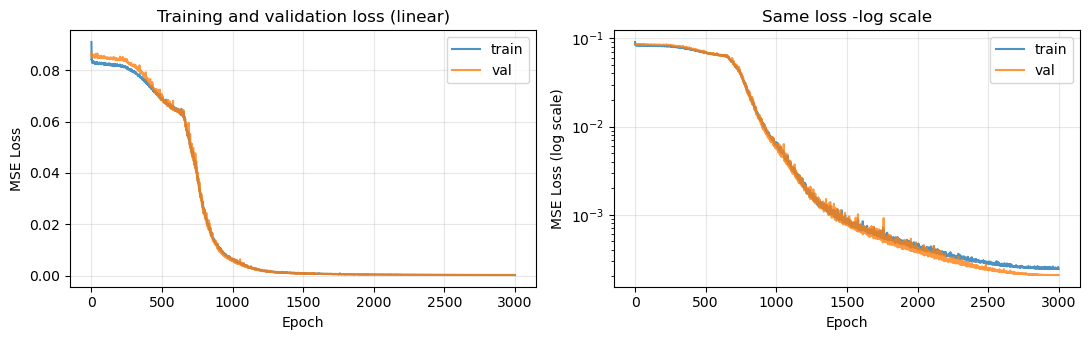

Final train MSE: 0.000243
Final val   MSE: 0.000207


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(train_losses, label="train", alpha=0.8)
axes[0].plot(val_losses,   label="val",   alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training and validation loss (linear)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(train_losses, label="train", alpha=0.8)
axes[1].semilogy(val_losses,   label="val",   alpha=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss (log scale)")
axes[1].set_title("Same loss -log scale")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.6f}")
print(f"Final val   MSE: {val_losses[-1]:.6f}")

---
## Visual Comparison: Ground Truth vs. MLP Prediction

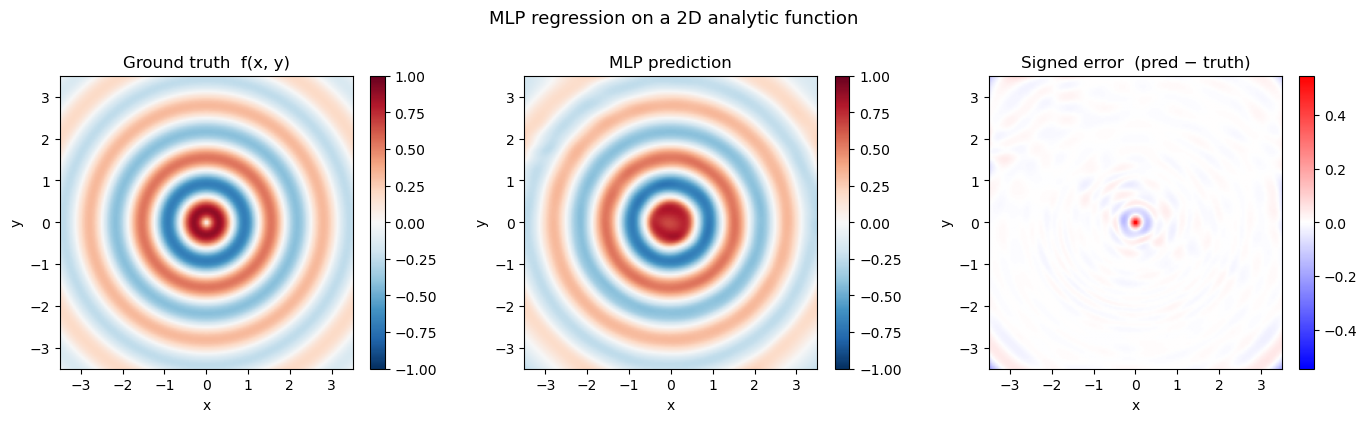

Max absolute error : 0.5448
Mean absolute error: 0.0076


In [8]:
# Evaluate the trained model on the same dense grid used for the ground-truth plot
model.eval()

# Flatten the grid into a (GRID_N^2, 2) batch, run through the model, reshape back
xy_flat = torch.stack([gx.flatten(), gy.flatten()], dim=1)  # (N², 2)
with torch.no_grad():
    gz_pred = model(xy_flat).reshape(GRID_N, GRID_N)         # (N, N)

gz_error = gz_pred - gz   # signed pointwise error

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(extent=[-extent, extent, -extent, extent], origin="lower",
          cmap="RdBu_r", vmin=-1, vmax=1)

im0 = axes[0].imshow(gz.numpy(),      **kw)
axes[0].set_title("Ground truth  f(x, y)")

im1 = axes[1].imshow(gz_pred.numpy(), **kw)
axes[1].set_title("MLP prediction")

err_max = gz_error.abs().max().item()
im2 = axes[2].imshow(gz_error.numpy(),
                     extent=[-extent, extent, -extent, extent],
                     origin="lower", cmap="bwr",
                     vmin=-err_max, vmax=err_max)
axes[2].set_title("Signed error  (pred − truth)")

for ax, im in zip(axes, [im0, im1, im2]):
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("MLP regression on a 2D analytic function", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Max absolute error : {gz_error.abs().max():.4f}")
print(f"Mean absolute error: {gz_error.abs().mean():.4f}")

---
## Cross-Section Comparison

Plotting the function along $y = 0$ lets us see the fit in 1-D. This makes it easier to
judge the errors in the oscillation phases and the amplitudes.

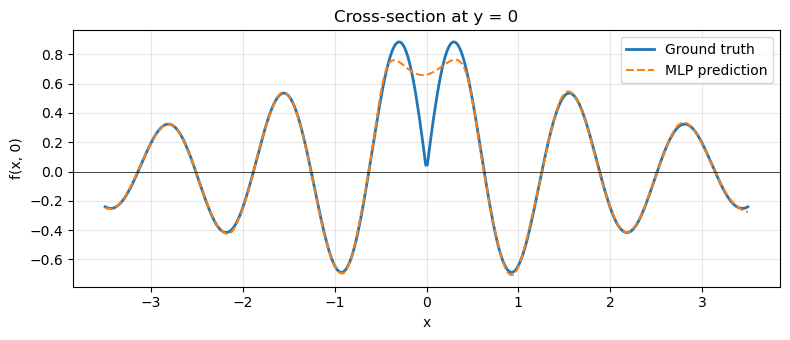

In [9]:
# Horizontal slice at y = 0
xs = torch.linspace(-extent, extent, 400)
xy_slice = torch.stack([xs, torch.zeros_like(xs)], dim=1)

gt_slice = target_fn(xs, torch.zeros_like(xs)).detach()
with torch.no_grad():
    pred_slice = model(xy_slice).squeeze().detach()

plt.figure(figsize=(8, 3.5))
plt.plot(xs.numpy(), gt_slice.numpy(),   label="Ground truth", lw=2)
plt.plot(xs.numpy(), pred_slice.numpy(), label="MLP prediction",
         lw=1.5, linestyle="--")
plt.axhline(0, color="k", lw=0.5)
plt.xlabel("x")
plt.ylabel("f(x, 0)")
plt.title("Cross-section at y = 0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Exercises: Things to Try for Yourself

1. **Change the target function.** Try `torch.sin(3*x) * torch.cos(3*y)` or
   a Gaussian bump `torch.exp(-(x**2 + y**2))`. Does the MLP fit them equally
   well? 

2. **Add noise to the training labels.** Change the data generation to
   `z_train = target_fn(...) + 0.1 * torch.randn(...)`. What happens to the
   train vs. validation loss gap?

3. **Reduce the model capacity.** Try `hidden=32, n_layers=1`. How much worse
   is the fit? What does the error image look like?

4. **Switch to ReLU.** Replace `nn.Tanh()` with `nn.ReLU()`. Are the
   "creases" from piecewise-linear activations visible in the prediction?

5. **Use the GPU.** Add `.to("cuda")` to the model and data tensors (if
   `torch.cuda.is_available()`) and measure the speedup with `time.time()`.

---
## Summary

| Step | What we did |
|------|-------------|
| Data | Sampled 8,000 random `(x, y)` pairs, evaluated the analytic target |
| Model | 3-hidden-layer MLP with Tanh activations, ~200k parameters |
| Loss | Mean-squared error (`nn.MSELoss`) |
| Optimizer | Adam with cosine learning-rate schedule |
| Training | Mini-batch loop: `zero_grad → forward → loss → backward → step` |
| Evaluation | `model.eval()` + `torch.no_grad()` on a held-out validation set |

Congratulations on finishing this tutorial series! 

We have shown you a widely used pattern in machine learning. This combines steps using a dataset, model, loss, optimizer, evaluating, and training loop. Approaches like this are scaled up all the way to current Large Language Models (LLMs) and other modern technologies. 

For more tutorials, machine learning codes, and related packages see our website https://web.atzberger.org/.
